# 🏡 Machine Learning for Design Inspiration Recommendation System

**Nhóm 13 – Machine Learning for Design | ĐHCN – ĐHQGHN**

---

### Pipeline tổng quan
```
User Query (text)
  → [1] Cài đặt & Import
  → [2] Load & Khám phá dữ liệu (EDA)
  → [3] Tiền xử lý (giữ nguyên từ nhóm)
  → [4] Train Style Classifier (RandomForest)
  → [5] Train Material Classifier (RandomForest)
  → [6] Train Color Regressor (MultiOutput RF)
  → [7] NLP Embedding (SentenceTransformer)
  → [8] Cosine Similarity Search
  → [9] Demo gợi ý đầy đủ
  → [10] Visualizations & Dashboard
  → [11] Lưu models
```

## 1. Cài đặt thư viện

In [41]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sentence_transformers import SentenceTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, r2_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.patches as mpatches
warnings.filterwarnings("ignore")


## 2. Load & Khám phá dữ liệu (EDA)

In [42]:
DATA_PATH = "dataset_cleaned_final.csv"
df = pd.read_csv(DATA_PATH)
df.head(5)

,Image_id,material_image_id,style_tags_boho,style_tags_industrial,style_tags_minimalist,style_tags_scandinavian,material_type_fabric,material_type_glass,material_type_leather,material_type_marble,material_type_metal,material_type_stone,material_type_tile,material_type_wood,clean_design_description,user_preference,color1,color2,color3
0,1,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,The raw vibe of this bathroom is perfectly com...,"wants a modern, urban atmosphere",#3020D7,#02A235,#DE15E9
1,2,2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,"This bathroom embraces a sleek design, highlig...",prefers simplicity and neutral palettes,#AE05EA,#341643,#2CA865
2,3,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,"Incorporating visible ductwork, this urban bed...","wants a modern, urban atmosphere",#7D8FE0,#7B30A7,#83CE64
3,4,4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"Beautifully styled, this bedroom offers textur...",likes vibrant colors and handmade decor,#CD1C51,#897AD6,#C05A75
4,5,5,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,A serene living room featuring rough cladding ...,prefers simplicity and neutral palettes,#760885,#9D13F1,#4D0B0E


# ── Định nghĩa cột style / material# ── Định nghĩa cột style / material

In [43]:
STYLE_COLS    = ["style_tags_boho", "style_tags_industrial",
                 "style_tags_minimalist", "style_tags_scandinavian"]
MATERIAL_COLS = ["material_type_fabric", "material_type_glass",
                 "material_type_leather", "material_type_marble",
                 "material_type_metal", "material_type_stone",
                 "material_type_tile", "material_type_wood"]

In [44]:
STYLE_NAMES    = [c.replace("style_tags_", "").capitalize()    for c in STYLE_COLS]
MATERIAL_NAMES = [c.replace("material_type_", "").capitalize() for c in MATERIAL_COLS]

# Tạo cột label từ one-hot
df["style_label"]    = df[STYLE_COLS].fillna(0).idxmax(axis=1).str.replace("style_tags_", "").str.capitalize()
df["material_label"] = df[MATERIAL_COLS].fillna(0).idxmax(axis=1).str.replace("material_type_", "").str.capitalize()

# Làm sạch cột màu
df["color1"] = df["color1"].str.strip()
df["color2"] = df["color2"].str.strip()
df["color3"] = df["color3"].str.strip()

print("Style distribution:")
print(df["style_label"].value_counts())
print()
print("Material distribution:")
print(df["material_label"].value_counts())

Style distribution:
style_label
Boho            259
Industrial      251
Minimalist      246
Scandinavian    244
Name: count, dtype: int64

Material distribution:
material_label
Fabric     137
Stone      134
Leather    132
Wood       128
Marble     122
Metal      119
Tile       117
Glass      111
Name: count, dtype: int64


### 📊 2. Trực quan hóa EDA

#### 2.1 Phân bố Style & Material Label

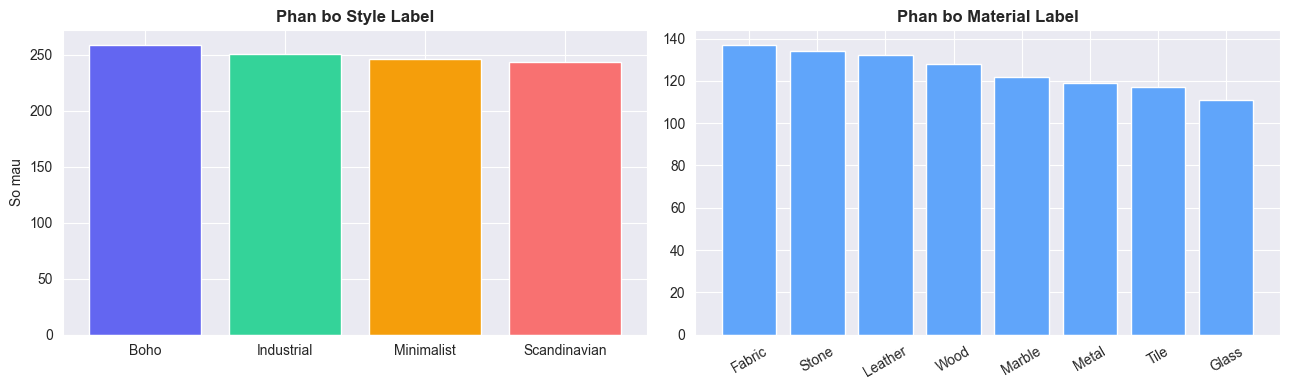

In [45]:
# 2.1 Phân bố Style & Material Label
fig_eda, axes_eda = plt.subplots(1, 2, figsize=(13, 4))
sc = df["style_label"].value_counts()
axes_eda[0].bar(sc.index, sc.values,
    color=["#6366f1","#34d399","#f59e0b","#f87171"], edgecolor="white")
axes_eda[0].set_title("Phan bo Style Label", fontweight="bold")
axes_eda[0].set_ylabel("So mau")
mc = df["material_label"].value_counts()
axes_eda[1].bar(mc.index, mc.values, color="#60a5fa", edgecolor="white")
axes_eda[1].set_title("Phan bo Material Label", fontweight="bold")
axes_eda[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()


#### 2.2 Phân bố độ dài mô tả thiết kế

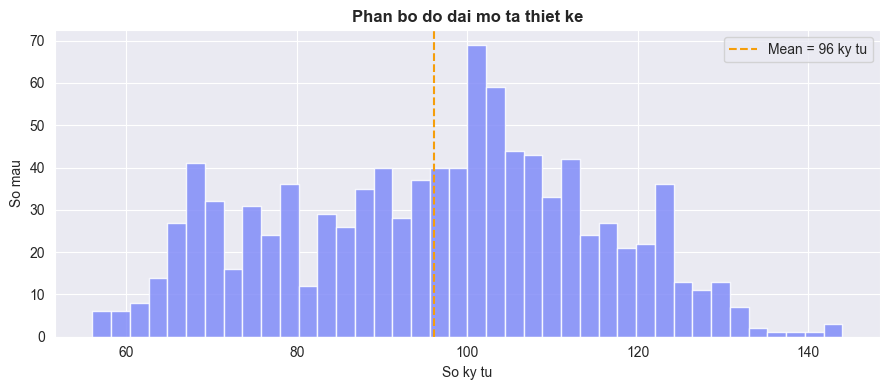

In [46]:
# 2.2 Phân bố độ dài mô tả thiết kế
df["desc_len"] = df["clean_design_description"].fillna("").apply(len)
plt.figure(figsize=(9, 4))
plt.hist(df["desc_len"], bins=40, color="#818cf8", edgecolor="white", alpha=0.85)
plt.axvline(df["desc_len"].mean(), color="#f59e0b", linestyle="--",
            label=f'Mean = {df["desc_len"].mean():.0f} ky tu')
plt.xlabel("So ky tu"); plt.ylabel("So mau")
plt.title("Phan bo do dai mo ta thiet ke", fontweight="bold")
plt.legend(); plt.tight_layout(); plt.show()


#### 2.3 Wordcloud – Mô tả thiết kế

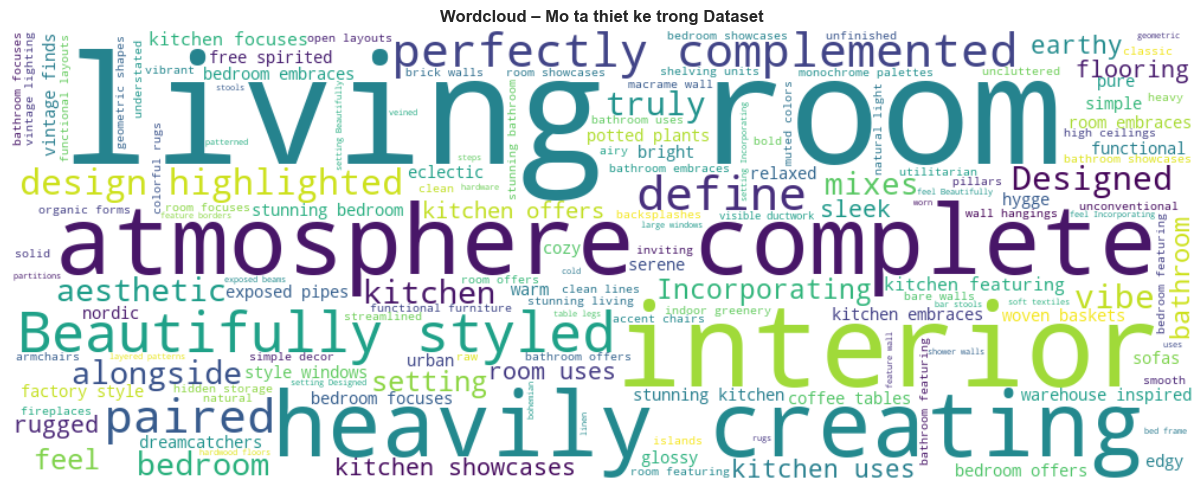

In [47]:
# 2.3 Wordcloud – Mô tả thiết kế
try:
    from wordcloud import WordCloud
    text_all = " ".join(df["clean_design_description"].dropna())
    wc = WordCloud(width=1000, height=380, background_color="white",
                   colormap="viridis", max_words=150).generate(text_all)
    plt.figure(figsize=(14, 5))
    plt.imshow(wc, interpolation="bilinear"); plt.axis("off")
    plt.title("Wordcloud – Mo ta thiet ke trong Dataset", fontweight="bold")
    plt.tight_layout(); plt.show()
except ImportError:
    print("Cai wordcloud: pip install wordcloud")


#### 2.4 Heatmap – Style × Material

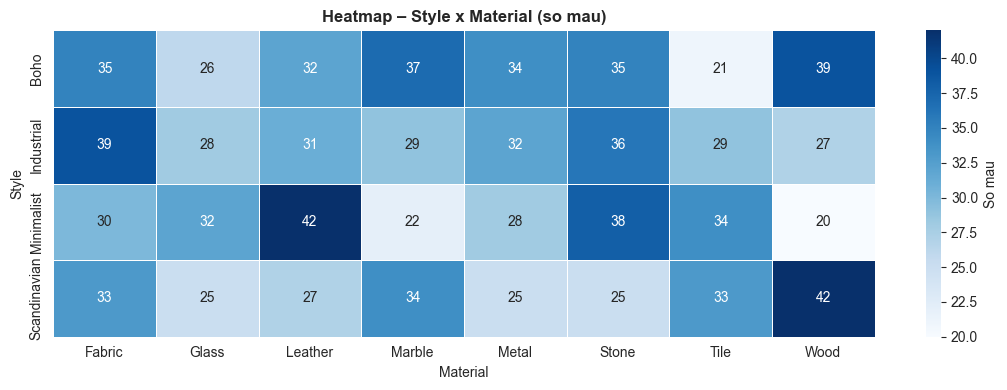

In [48]:
# 2.4 Heatmap – Style x Material
import seaborn as sns
cross = pd.crosstab(df["style_label"], df["material_label"])
plt.figure(figsize=(11, 4))
sns.heatmap(cross, annot=True, fmt="d", cmap="Blues", linewidths=0.5,
            cbar_kws={"label": "So mau"})
plt.title("Heatmap – Style x Material (so mau)", fontweight="bold")
plt.ylabel("Style"); plt.xlabel("Material")
plt.tight_layout(); plt.show()


## 3. Tiền xử lý dữ liệu

> ✅ **Giữ nguyên code gốc từ notebook nhóm** – chỉ bổ sung phần chuẩn bị features cho ML models.

In [49]:
# ── CODE GỐC NHÓM: clean_text ────────────────────────────────────────────────
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# Verify: áp dụng lại trên df (đã có trong dataset_cleaned_final.csv)
# df["clean_design_description"] = df["design_description"].apply(clean_text)
print("✓ clean_text function sẵn sàng")
print("Sample:", clean_text("Gian bếp tối giản bằng gỗ!"))

✓ clean_text function sẵn sàng
Sample: gian bếp tối giản bằng gỗ


In [50]:
# ── Chuẩn bị feature matrix & target vectors ─────────────────────────────────


# Tạo TF-IDF vectorizer cho văn bản mô tả thiết kế
# Dùng max_features=500 để giới hạn kích thước, loại bỏ stop words
tfidf_style = TfidfVectorizer(max_features=500, stop_words='english')
tfidf_material = TfidfVectorizer(max_features=500, stop_words='english')

texts = df["clean_design_description"].fillna("").tolist()

X_style = tfidf_style.fit_transform(texts)
X_material = tfidf_material.fit_transform(texts)

# Lấy nhãn
y_style_idx = df[STYLE_COLS].fillna(0).values.argmax(axis=1)
y_style     = [STYLE_NAMES[i] for i in y_style_idx]

y_mat_idx   = df[MATERIAL_COLS].fillna(0).values.argmax(axis=1)
y_material  = [MATERIAL_NAMES[i] for i in y_mat_idx]

print(f"X_style shape:    {X_style.shape} (TF-IDF features)")
print(f"y_style labels:   {set(y_style)}")
print(f"X_material shape: {X_material.shape}")

X_style shape:    (1000, 247) (TF-IDF features)
y_style labels:   {'Minimalist', 'Scandinavian', 'Industrial', 'Boho'}
X_material shape: (1000, 247)


## 4. Mô hình phân loại Style (RandomForest Classifier)

In [51]:
# ── Train / Test split ────────────────────────────────────────────────────────
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_style, y_style, test_size=0.2, random_state=42, stratify=y_style)

print(f"Train size (Style): {X_tr_s.shape[0]}")
print(f"Test size  (Style): {X_te_s.shape[0]}")

Train size (Style): 800
Test size  (Style): 200


In [52]:
# ── Huấn luyện ───────────────────────────────────────────────────────────────
style_clf = RandomForestClassifier(
    n_estimators=200, max_depth=7, random_state=42, n_jobs=-1)
style_clf.fit(X_tr_s, y_tr_s)

y_pred_s = style_clf.predict(X_te_s)
acc_s    = accuracy_score(y_te_s, y_pred_s)
print(f"Style Classifier Accuracy: {acc_s:.4f}")
print()
print(classification_report(y_te_s, y_pred_s))

Style Classifier Accuracy: 0.9500

              precision    recall  f1-score   support

        Boho       0.91      0.98      0.94        52
  Industrial       0.98      0.98      0.98        50
  Minimalist       1.00      0.92      0.96        49
Scandinavian       0.92      0.92      0.92        49

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



### 4a. So sánh với SVM (Support Vector Machine)

In [53]:
from sklearn.svm import SVC

# 1. Khởi tạo mô hình SVM cho bài toán Style
svm_style = SVC(kernel='linear', random_state=42) # Bạn có thể đổi kernel tùy ý (rbf, poly...)

# 2. Huấn luyện mô hình với dữ liệu Train của Style
# (Hãy đảm bảo X_tr_s và y_tr_s là tên chính xác của tập train bạn đã chia ở trên)
svm_style.fit(X_tr_s, y_tr_s)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [54]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# --- Huấn luyện mô hình so sánh (Support Vector Machine) ---
style_svm_clf = SVC(kernel='rbf', C=1.0, random_state=42)
style_svm_clf.fit(X_tr_s, y_tr_s)

# --- Dự đoán và Đánh giá ---
y_pred_svm = style_svm_clf.predict(X_te_s)
acc_svm = accuracy_score(y_te_s, y_pred_svm)

print(f"SVM Classifier Accuracy: {acc_svm:.4f}")
print("-" * 40)
print(classification_report(y_te_s, y_pred_svm))

SVM Classifier Accuracy: 0.9750
----------------------------------------
              precision    recall  f1-score   support

        Boho       0.98      0.96      0.97        52
  Industrial       1.00      0.98      0.99        50
  Minimalist       0.98      0.98      0.98        49
Scandinavian       0.94      0.98      0.96        49

    accuracy                           0.97       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.97      0.98       200



### 📊 4. Trực quan hóa Style Classifier

#### 4.1 Confusion Matrix – RF vs SVM

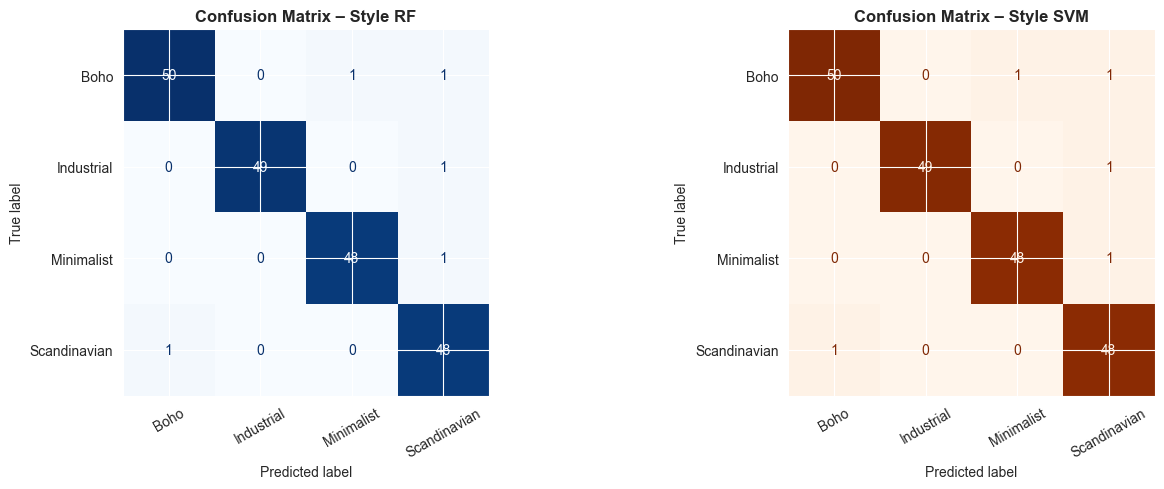

In [55]:
# 4.1 Confusion Matrix – Style RF vs SVM
import matplotlib.patches as mpatches
from sklearn.metrics import ConfusionMatrixDisplay

fig_cm_s, axes_cm_s = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(
    y_te_s, style_svm_clf.predict(X_te_s),
    ax=axes_cm_s[0], colorbar=False, cmap="Blues", display_labels=STYLE_NAMES)
axes_cm_s[0].set_title("Confusion Matrix – Style RF", fontweight="bold")
axes_cm_s[0].tick_params(axis='x', rotation=30)
ConfusionMatrixDisplay.from_predictions(
    y_te_s, style_svm_clf.predict(X_te_s),
    ax=axes_cm_s[1], colorbar=False, cmap="Oranges", display_labels=STYLE_NAMES)
axes_cm_s[1].set_title("Confusion Matrix – Style SVM", fontweight="bold")
axes_cm_s[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()


#### 4.2 So sánh Accuracy – RF vs SVM

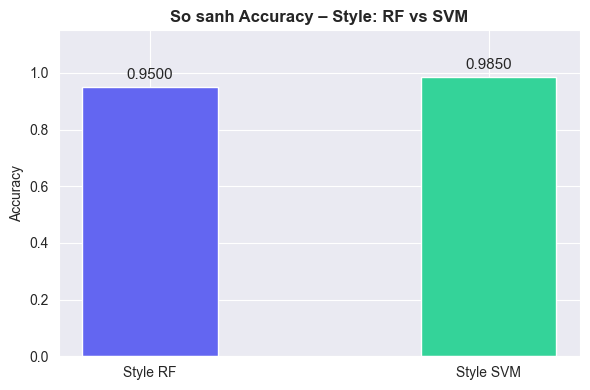

In [56]:
# 4.2 So sánh Accuracy – Style RF vs SVM
from sklearn.metrics import accuracy_score
acc_rf  = accuracy_score(y_te_s, style_clf.predict(X_te_s))
acc_svm = accuracy_score(y_te_s, svm_style.predict(X_te_s))
plt.figure(figsize=(6, 4))
bars = plt.bar(["Style RF", "Style SVM"], [acc_rf, acc_svm],
               color=["#6366f1","#34d399"], edgecolor="white", width=0.4)
plt.bar_label(bars, fmt="%.4f", padding=4, fontsize=11)
plt.ylim(0, 1.15); plt.ylabel("Accuracy")
plt.title("So sanh Accuracy – Style: RF vs SVM", fontweight="bold")
plt.tight_layout(); plt.show()


#### 4.3 Feature Importance – Style RF (Top 15 TF-IDF)

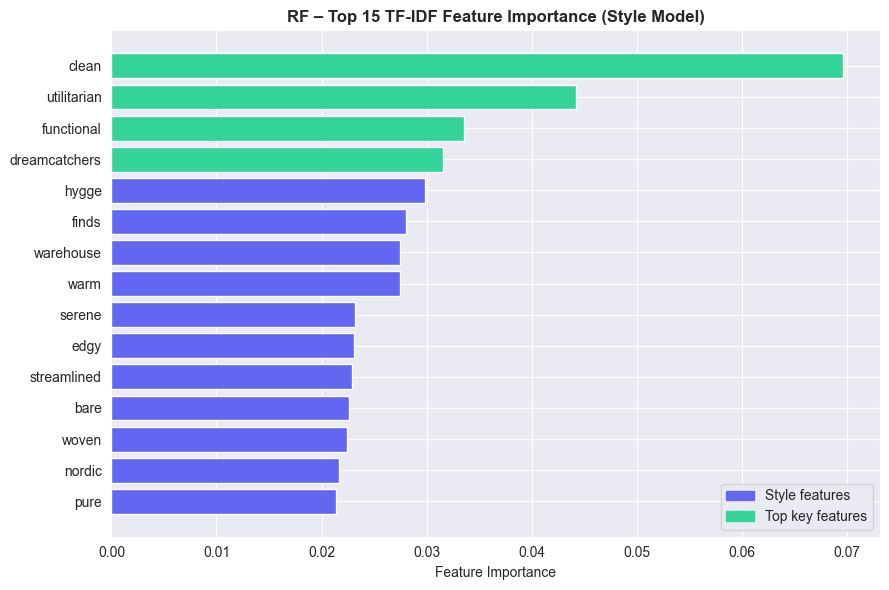

In [57]:
# 4.3 Feature Importance – Style RF (Top 15)
import matplotlib.patches as mpatches
feat_names_s = tfidf_style.get_feature_names_out()
fi_s = style_clf.feature_importances_
order_s = np.argsort(fi_s)[-15:]
bar_colors_s = ["#6366f1" if i < 11 else "#34d399" for i in range(15)]
plt.figure(figsize=(9, 6))
plt.barh([feat_names_s[i] for i in order_s], fi_s[order_s], color=bar_colors_s)
plt.xlabel("Feature Importance")
plt.title("RF – Top 15 TF-IDF Feature Importance (Style Model)", fontweight="bold")
legend_elems = [mpatches.Patch(color="#6366f1", label="Style features"),
                mpatches.Patch(color="#34d399", label="Top key features")]
plt.legend(handles=legend_elems, loc="lower right")
plt.tight_layout(); plt.show()


## 5. Mô hình phân loại Material (RandomForest Classifier)

In [58]:
# ── Huấn luyện Material Classifier ─────────────────────────────────────────────
X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    X_material, y_material, test_size=0.2, random_state=42, stratify=y_material)

material_clf = RandomForestClassifier(
    n_estimators=500, max_depth=10, random_state=42, n_jobs=-1)
material_clf.fit(X_tr_m, y_tr_m)

y_pred_m = material_clf.predict(X_te_m)
print(f"Accuracy (Material Model): {accuracy_score(y_te_m, y_pred_m):.4f}")
print("\nClassification Report:")
print(classification_report(y_te_m, y_pred_m))

Accuracy (Material Model): 0.8800

Classification Report:
              precision    recall  f1-score   support

      Fabric       0.74      0.96      0.84        27
       Glass       1.00      0.91      0.95        22
     Leather       0.92      0.88      0.90        26
      Marble       0.81      0.84      0.82        25
       Metal       0.91      0.83      0.87        24
       Stone       0.86      0.93      0.89        27
        Tile       0.91      0.87      0.89        23
        Wood       1.00      0.81      0.89        26

    accuracy                           0.88       200
   macro avg       0.89      0.88      0.88       200
weighted avg       0.89      0.88      0.88       200



### 5a. So sánh với SVM (Support Vector Machine)

In [59]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# --- Huấn luyện mô hình so sánh (Support Vector Machine) ---
material_svm_clf = SVC(kernel='rbf', C=0.5, random_state=42)
material_svm_clf.fit(X_tr_m, y_tr_m)

# --- Dự đoán và Đánh giá ---
y_pred_svm = material_svm_clf.predict(X_te_m)
acc_svm = accuracy_score(y_te_m, y_pred_svm)

print(f"SVM Classifier Accuracy: {acc_svm:.4f}")
print("-" * 40)
print(classification_report(y_te_m, y_pred_svm))

SVM Classifier Accuracy: 0.9450
----------------------------------------
              precision    recall  f1-score   support

      Fabric       1.00      1.00      1.00        27
       Glass       1.00      0.91      0.95        22
     Leather       0.96      1.00      0.98        26
      Marble       0.85      0.92      0.88        25
       Metal       0.96      0.92      0.94        24
       Stone       0.87      0.96      0.91        27
        Tile       0.96      1.00      0.98        23
        Wood       1.00      0.85      0.92        26

    accuracy                           0.94       200
   macro avg       0.95      0.94      0.95       200
weighted avg       0.95      0.94      0.95       200



### 📊 5. Trực quan hóa Material Classifier

#### 5.1 Confusion Matrix – RF vs SVM

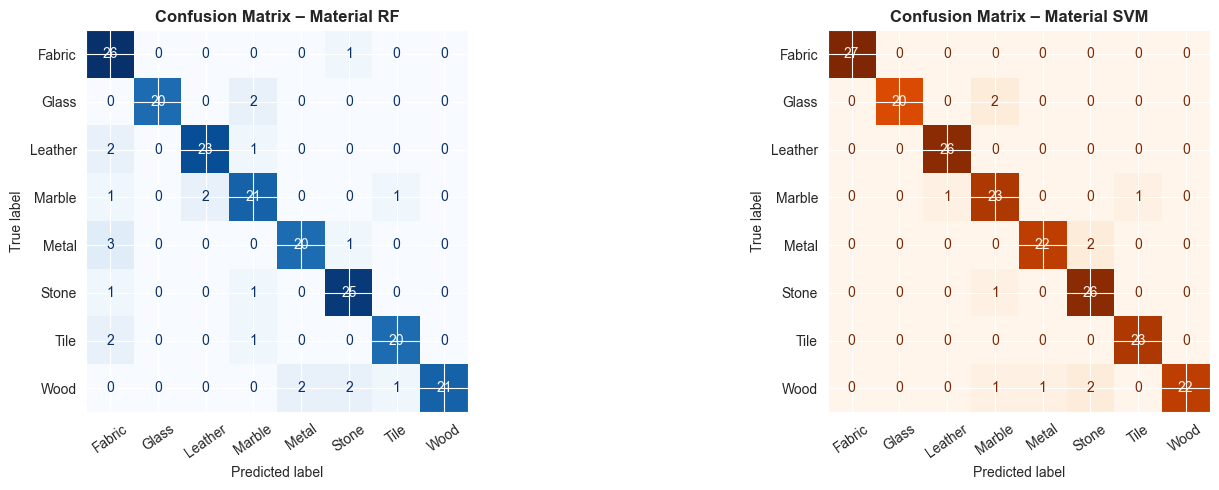

In [60]:
# 5.1 Confusion Matrix – Material RF vs SVM
from sklearn.metrics import ConfusionMatrixDisplay

fig_cm_m, axes_cm_m = plt.subplots(1, 2, figsize=(16, 5))
ConfusionMatrixDisplay.from_predictions(
    y_te_m, material_clf.predict(X_te_m),
    ax=axes_cm_m[0], colorbar=False, cmap="Blues", display_labels=MATERIAL_NAMES)
axes_cm_m[0].set_title("Confusion Matrix – Material RF", fontweight="bold")
axes_cm_m[0].tick_params(axis='x', rotation=35)
ConfusionMatrixDisplay.from_predictions(
    y_te_m, material_svm_clf.predict(X_te_m),
    ax=axes_cm_m[1], colorbar=False, cmap="Oranges", display_labels=MATERIAL_NAMES)
axes_cm_m[1].set_title("Confusion Matrix – Material SVM", fontweight="bold")
axes_cm_m[1].tick_params(axis='x', rotation=35)
plt.tight_layout(); plt.show()


#### 5.2 So sánh Accuracy – RF vs SVM

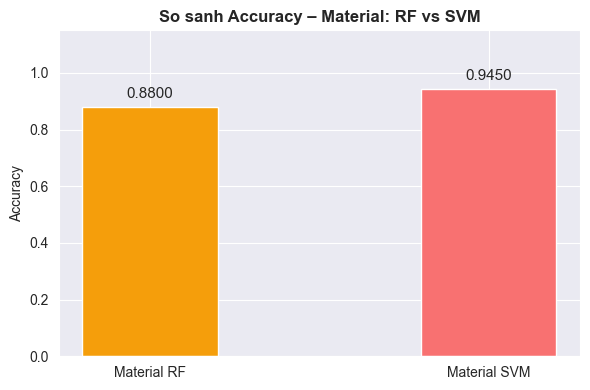

In [61]:
# 5.2 So sánh Accuracy – Material RF vs SVM
from sklearn.metrics import accuracy_score
acc_m_rf  = accuracy_score(y_te_m, material_clf.predict(X_te_m))
acc_m_svm = accuracy_score(y_te_m, material_svm_clf.predict(X_te_m))
plt.figure(figsize=(6, 4))
bars2 = plt.bar(["Material RF", "Material SVM"], [acc_m_rf, acc_m_svm],
                color=["#f59e0b","#f87171"], edgecolor="white", width=0.4)
plt.bar_label(bars2, fmt="%.4f", padding=4, fontsize=11)
plt.ylim(0, 1.15); plt.ylabel("Accuracy")
plt.title("So sanh Accuracy – Material: RF vs SVM", fontweight="bold")
plt.tight_layout(); plt.show()


#### 5.3 Feature Importance – Material RF (Top 15 TF-IDF)

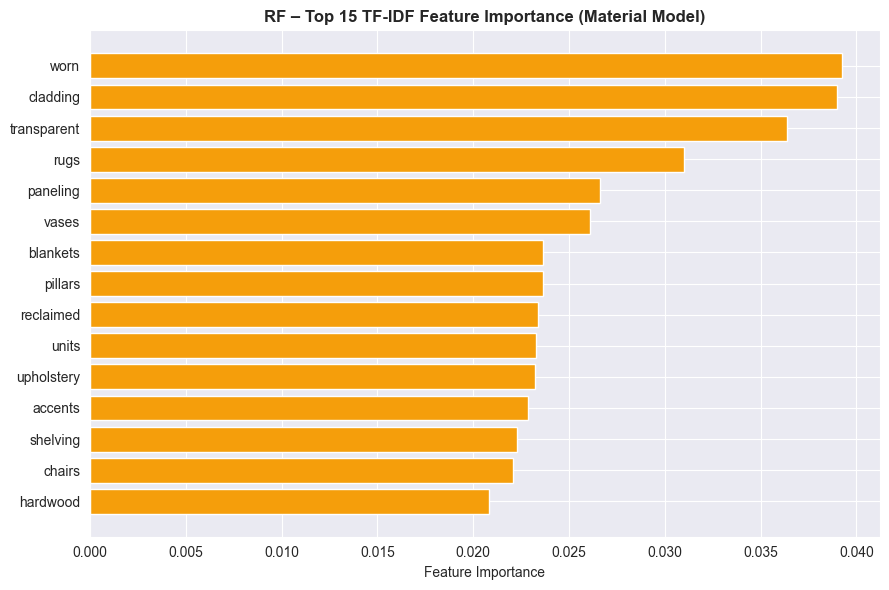

In [62]:
# 5.3 Feature Importance – Material RF (Top 15)
feat_names_m = tfidf_material.get_feature_names_out()
fi_m = material_clf.feature_importances_
order_m = np.argsort(fi_m)[-15:]
plt.figure(figsize=(9, 6))
plt.barh([feat_names_m[i] for i in order_m], fi_m[order_m], color="#f59e0b")
plt.xlabel("Feature Importance")
plt.title("RF – Top 15 TF-IDF Feature Importance (Material Model)", fontweight="bold")
plt.tight_layout(); plt.show()


## 6. Mô hình hồi quy màu sắc (MultiOutput RandomForest Regressor)

Dự đoán 9 giá trị (R,G,B) × 3 màu từ feature vector.

In [63]:
# ── Chuẩn bị feature matrix & target vectors ─────────────────────────────────

# Tạo TF-IDF vectorizer cho văn bản mô tả thiết kế
# Dùng max_features=500 để giới hạn kích thước, loại bỏ stop words
tfidf_style = TfidfVectorizer(max_features=500, stop_words='english')
tfidf_material = TfidfVectorizer(max_features=500, stop_words='english')

texts = df["clean_design_description"].fillna("").tolist()

X_style = tfidf_style.fit_transform(texts)
X_material = tfidf_material.fit_transform(texts)

# Lấy nhãn
y_style_idx = df[STYLE_COLS].fillna(0).values.argmax(axis=1)
y_style     = [STYLE_NAMES[i] for i in y_style_idx]

y_mat_idx   = df[MATERIAL_COLS].fillna(0).values.argmax(axis=1)
y_material  = [MATERIAL_NAMES[i] for i in y_mat_idx]

print(f"X_style shape:    {X_style.shape} (TF-IDF features)")
print(f"y_style labels:   {set(y_style)}")
print(f"X_material shape: {X_material.shape}")

X_style shape:    (1000, 247) (TF-IDF features)
y_style labels:   {'Minimalist', 'Scandinavian', 'Industrial', 'Boho'}
X_material shape: (1000, 247)


In [64]:
# ── Section 6: Color Regression Model ────────────────────────────────────────
def hex_to_rgb(hex_str: str) -> tuple:
    try:
        h = str(hex_str).strip().lstrip("#")
        return tuple(int(h[i:i+2], 16) for i in (0, 2, 4))
    except Exception:
        return (128, 128, 128)

rgb_matrix = []
for _, row in df.iterrows():
    r1,g1,b1 = hex_to_rgb(row["color1"])
    r2,g2,b2 = hex_to_rgb(row["color2"])
    r3,g3,b3 = hex_to_rgb(row["color3"])
    rgb_matrix.append([r1,g1,b1, r2,g2,b2, r3,g3,b3])
y_color = np.array(rgb_matrix, dtype=float)

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_style, y_color, test_size=0.2, random_state=42)

color_reg = MultiOutputRegressor(
    RandomForestRegressor(n_estimators=50, max_depth=6, random_state=42, n_jobs=-1))
color_reg.fit(X_tr_c, y_tr_c)

y_pred_c = color_reg.predict(X_te_c)
print(f"Color Model R² (test): {r2_score(y_te_c, y_pred_c, multioutput='uniform_average'):.4f}")


Color Model R² (test): -0.0125


### 📊 6. Trực quan hóa Color Regressor

#### 6.1 Predicted vs Actual – Color Swatches (10 mẫu đầu)

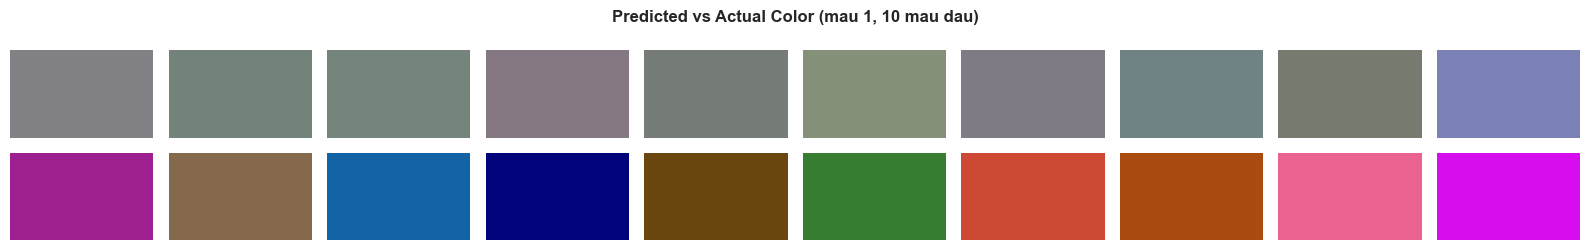

In [65]:
# 6.1 Predicted vs Actual – Color Swatches (10 mẫu đầu)
n_show       = 10
pred_clipped = np.clip(y_pred_c[:n_show], 0, 255).astype(int)
actual_c     = y_te_c[:n_show].astype(int)

fig_sw, axes_sw = plt.subplots(2, n_show, figsize=(16, 2.5))
for i in range(n_show):
    rgb_p = tuple(int(v) for v in pred_clipped[i, 0:3])
    axes_sw[0, i].add_patch(plt.Rectangle((0,0),1,1, color=[v/255 for v in rgb_p]))
    axes_sw[0, i].set_xlim(0,1); axes_sw[0, i].set_ylim(0,1); axes_sw[0, i].axis("off")
    if i == 0: axes_sw[0, i].set_ylabel("Pred", fontsize=9)
    rgb_a = tuple(int(v) for v in actual_c[i, 0:3])
    axes_sw[1, i].add_patch(plt.Rectangle((0,0),1,1, color=[v/255 for v in rgb_a]))
    axes_sw[1, i].set_xlim(0,1); axes_sw[1, i].set_ylim(0,1); axes_sw[1, i].axis("off")
    if i == 0: axes_sw[1, i].set_ylabel("Actual", fontsize=9)
fig_sw.suptitle("Predicted vs Actual Color (mau 1, 10 mau dau)", fontweight="bold")
plt.tight_layout(); plt.show()


#### 6.2 Scatter Predicted vs Actual – Từng kênh R, G, B

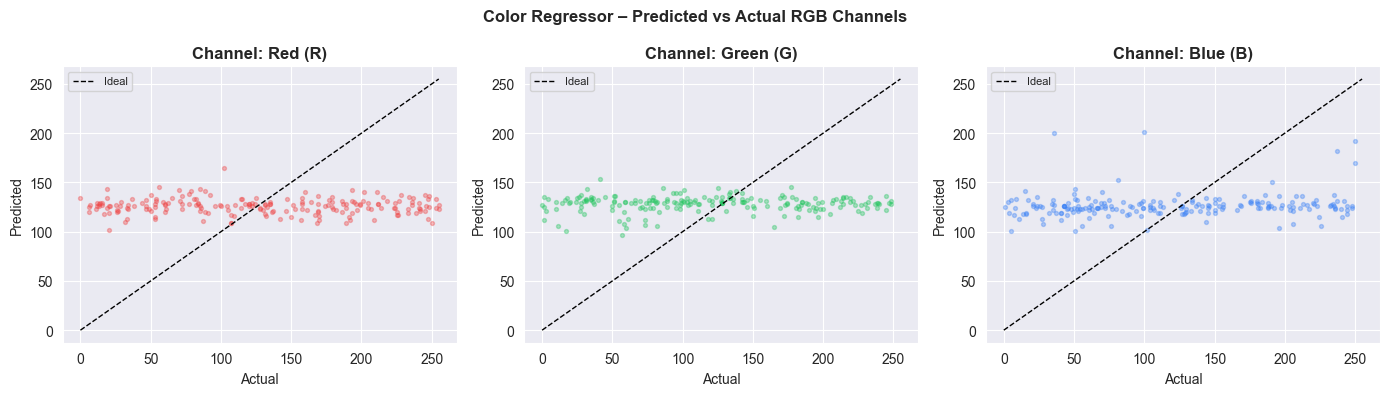

In [66]:
# 6.2 Scatter Predicted vs Actual – Từng kênh R, G, B
fig_rgb, axes_rgb = plt.subplots(1, 3, figsize=(14, 4))
ch_names  = ["Red (R)", "Green (G)", "Blue (B)"]
ch_colors = ["#ef4444", "#22c55e", "#3b82f6"]
for ch in range(3):
    ax = axes_rgb[ch]
    ax.scatter(y_te_c[:, ch], y_pred_c[:, ch], alpha=0.35, s=8, color=ch_colors[ch])
    ax.plot([0, 255], [0, 255], "k--", lw=1, label="Ideal")
    ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
    ax.set_title(f"Channel: {ch_names[ch]}", fontweight="bold")
    ax.legend(fontsize=8)
plt.suptitle("Color Regressor – Predicted vs Actual RGB Channels", fontweight="bold")
plt.tight_layout(); plt.show()


#### 6.3 Color Palette từ Dataset (80 mẫu đầu)

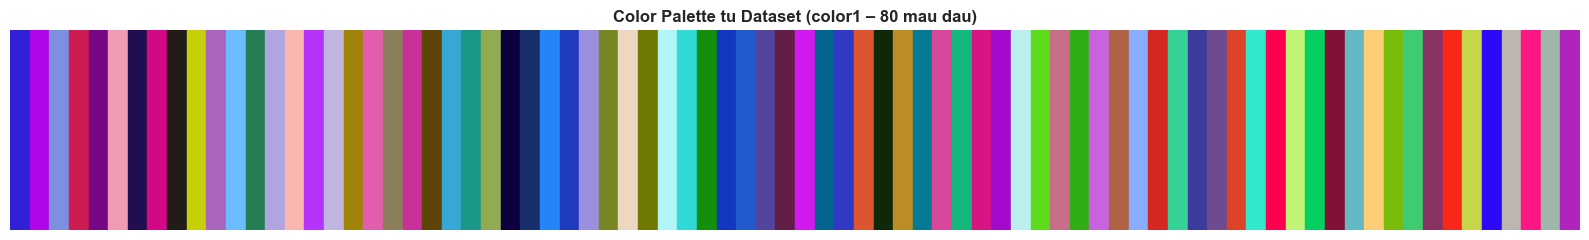

In [67]:
# 6.3 Color Palette từ Dataset (80 mẫu đầu)
valid_hex = df["color1"].dropna().head(80).str.strip()
valid_hex = [c for c in valid_hex if re.match(r'^#[0-9A-Fa-f]{6}$', c)]
fig_pal, ax_pal = plt.subplots(figsize=(16, 2.5))
ax_pal.set_xlim(0, len(valid_hex)); ax_pal.set_ylim(0, 1)
for i, hex_c in enumerate(valid_hex):
    rgb = tuple(int(hex_c.lstrip("#")[j:j+2], 16)/255 for j in (0, 2, 4))
    ax_pal.add_patch(plt.Rectangle((i, 0), 1, 1, color=rgb))
ax_pal.axis("off")
ax_pal.set_title("Color Palette tu Dataset (color1 – 80 mau dau)", fontweight="bold")
plt.tight_layout(); plt.show()


## 7. NLP Embedding – SentenceTransformer

Dùng `all-MiniLM-L6-v2` để chuyển câu mô tả → vector 384 chiều.
Embedding được cache vào `description_embeddings.pkl` để tránh encode lại.

In [68]:
print("Loading SentenceTransformer all-MiniLM-L6-v2 …")
st_model = SentenceTransformer("all-MiniLM-L6-v2")
print("✓ Model loaded")

# In-memory cache
_query_cache = {}

def encode_query(text: str) -> np.ndarray:
    if text not in _query_cache:
        _query_cache[text] = st_model.encode([text], normalize_embeddings=True)
    return _query_cache[text]


Loading SentenceTransformer all-MiniLM-L6-v2 …


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9362.89it/s]


✓ Model loaded


In [69]:
# ── Encode toàn bộ dataset (cache vào file) ──────────────────────────────────

EMB_PATH = "description_embeddings.pkl"
ST_MODEL_NAME = "all-MiniLM-L6-v2"

dataset_embeddings = None
if os.path.exists(EMB_PATH):
    cached_data = joblib.load(EMB_PATH)
    if isinstance(cached_data, dict) and cached_data.get("model_name") == ST_MODEL_NAME:
        dataset_embeddings = cached_data["embeddings"]
        print(f"✓ Loaded embeddings from cache: {dataset_embeddings.shape}")

if dataset_embeddings is None:
    print(f"Encoding {len(df)} descriptions …")
    texts = df["clean_design_description"].fillna("").tolist()
    dataset_embeddings = st_model.encode(texts, normalize_embeddings=True, show_progress_bar=True, batch_size=64)
    joblib.dump({"model_name": ST_MODEL_NAME, "embeddings": dataset_embeddings}, EMB_PATH)
    print(f"✓ Saved embeddings: {dataset_embeddings.shape}")


✓ Loaded embeddings from cache: (1000, 384)


### 📊 7. Trực quan hóa NLP Embedding

#### 7.1 t-SNE – Sentence Embeddings 2D theo Style Label

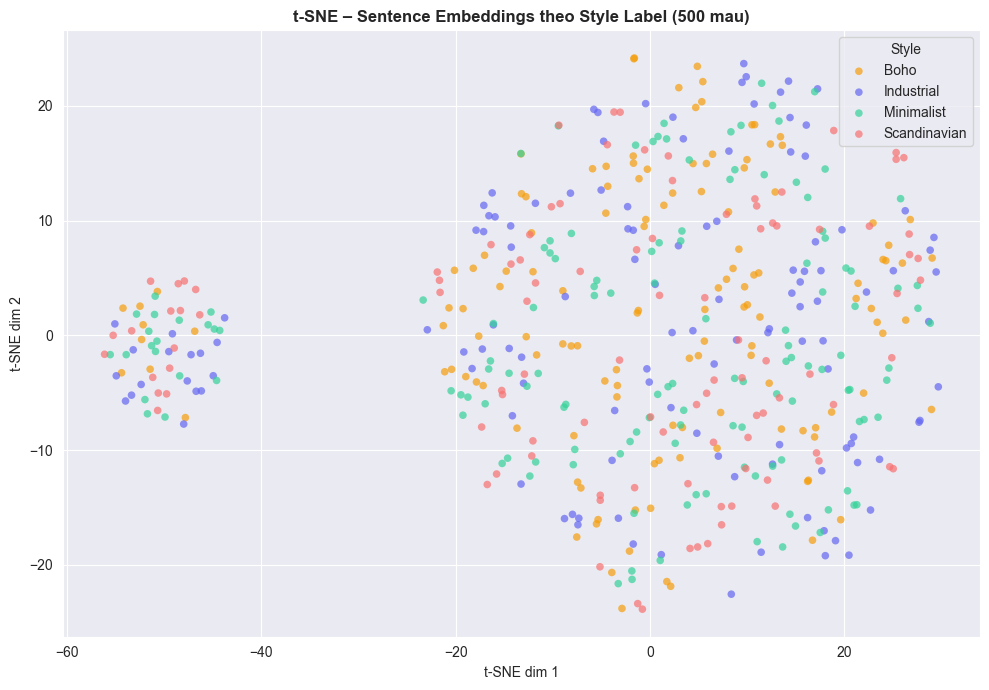

In [71]:
# 7.1 t-SNE – Sentence Embeddings 2D theo Style Label
from sklearn.manifold import TSNE
n_tsne = min(500, len(dataset_embeddings))
tsne   = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
emb_2d = tsne.fit_transform(dataset_embeddings[:n_tsne])
style_plot = df["style_label"].values[:n_tsne]
palette_tsne = {"Boho":"#f59e0b","Industrial":"#6366f1",
                "Minimalist":"#34d399","Scandinavian":"#f87171"}
plt.figure(figsize=(10, 7))
for sname, color in palette_tsne.items():
    mask = style_plot == sname
    plt.scatter(emb_2d[mask,0], emb_2d[mask,1],
                label=sname, color=color, alpha=0.7, s=30, edgecolors="none")
plt.legend(title="Style", fontsize=10)
plt.title(f"t-SNE – Sentence Embeddings theo Style Label ({n_tsne} mau)", fontweight="bold")
plt.xlabel("t-SNE dim 1"); plt.ylabel("t-SNE dim 2")
plt.tight_layout(); plt.show()


## 8. Cosine Similarity Search

In [72]:
def recommend(query: str, top_n: int = 3,
              style_filter: str = None, material_filter: str = None) -> pd.DataFrame:
    q_emb = encode_query(query)

    mask = pd.Series([True] * len(df), index=df.index)
    if style_filter:
        mask &= (df["style_label"].str.lower() == style_filter.lower())
    if material_filter:
        mask &= (df["material_label"].str.lower() == material_filter.lower())

    final_idx = df.index[mask].tolist()
    if len(final_idx) < top_n:
        final_idx = df.index.tolist()

    filt_embs = dataset_embeddings[final_idx]
    sims = cosine_similarity(q_emb, filt_embs)[0]

    result = df.loc[final_idx].copy()
    result["similarity"] = sims

    top = result.nlargest(top_n, "similarity").reset_index(drop=True)
    return top[["Image_id", "style_label", "material_label", "color1", "color2", "color3", "similarity", "clean_design_description"]]


## 9. Helper Functions & Demo đầy đủ

In [73]:
# ── TF-IDF Vectors ────────────────────────────
def build_feature_vector_style(query: str):
    return tfidf_style.transform([clean_text(query)])

def build_feature_vector_material(query: str):
    return tfidf_material.transform([clean_text(query)])

COLOR_PALETTE_TABLE = {
    ("Boho", "Fabric"):  ["#C19A6B", "#D2691E", "#8B4513"],
    ("Minimalist", "Wood"):    ["#F5F5DC", "#D2B48C", "#FFFFFF"],
    ("Industrial", "Metal"):   ["#708090", "#2F4F4F", "#36454F"],
    ("Scandinavian", "Wood"):  ["#DEB887", "#F5DEB3", "#FFFAF0"],
}
def get_predicted_palette(style, material):
    key = (style, material)
    if key in COLOR_PALETTE_TABLE: return COLOR_PALETTE_TABLE[key]
    style_defaults = {"Boho": ["#C19A6B", "#D2691E", "#8B4513"], "Industrial": ["#708090", "#2F4F4F", "#36454F"], "Minimalist": ["#F5F5F5", "#E8E8E8", "#D3D3D3"], "Scandinavian": ["#DEB887", "#F5DEB3", "#FFFAF0"]}
    return style_defaults.get(style, ["#808080", "#A9A9A9", "#DCDCDC"])


In [74]:
# ── DEMO ĐẦY ĐỦ ──────────────────────────────────────────────────────────────
DEMO_QUERIES = [
    "phòng ngủ hiện đại",
    "Phòng khách công nghiệp với kim loại và bê tông",
    "Không gian Scandinavian ấm cúng tự nhiên",
    "Phòng ngủ Boho đầy cây và vải thủ công",
]

for query in DEMO_QUERIES:
    print("═" * 62)
    print(f"Query : {query}")

    X_q_s  = build_feature_vector_style(query)
    X_q_m  = build_feature_vector_material(query)

    style_pred    = style_clf.predict(X_q_s)[0]
    material_pred = material_clf.predict(X_q_m)[0]

    hex_colors = get_predicted_palette(style_pred, material_pred)

    print(f"  Style    : {style_pred}")
    print(f"  Material : {material_pred}")
    print(f"  Palette  : {hex_colors}")

    top3 = recommend(query, top_n=3, style_filter=style_pred, material_filter=material_pred)
    for _, row in top3.iterrows():
        sim_pct = row["similarity"] * 100
        print(f"  [{sim_pct:5.1f}%] #{int(row['Image_id'])} {row['style_label']}/{row['material_label']} – {row['clean_design_description'][:52]}…")
    print()


══════════════════════════════════════════════════════════════
Query : phòng ngủ hiện đại
  Style    : Industrial
  Material : Fabric
  Palette  : ['#708090', '#2F4F4F', '#36454F']
  [ 11.4%] #886 Industrial/Fabric – A stunning bedroom that mixes brick walls with uphol…
  [ 10.9%] #121 Industrial/Fabric – Designed with an utilitarian aesthetic, this bathroo…
  [ 10.7%] #679 Industrial/Fabric – A stunning living room that mixes high ceilings with…

══════════════════════════════════════════════════════════════
Query : Phòng khách công nghiệp với kim loại và bê tông
  Style    : Industrial
  Material : Fabric
  Palette  : ['#708090', '#2F4F4F', '#36454F']
  [ 11.0%] #779 Industrial/Fabric – A stunning kitchen that mixes brick walls with uphol…
  [ 10.9%] #990 Industrial/Fabric – The interior of this living room uses upholstered so…
  [  9.6%] #819 Industrial/Fabric – Beautifully styled, this kitchen offers soft draperi…

══════════════════════════════════════════════════════════════
Quer

### 📊 9. Trực quan hóa Cosine Similarity Search

#### 9.1 Phân bố Cosine Similarity – Query vs Toàn Dataset

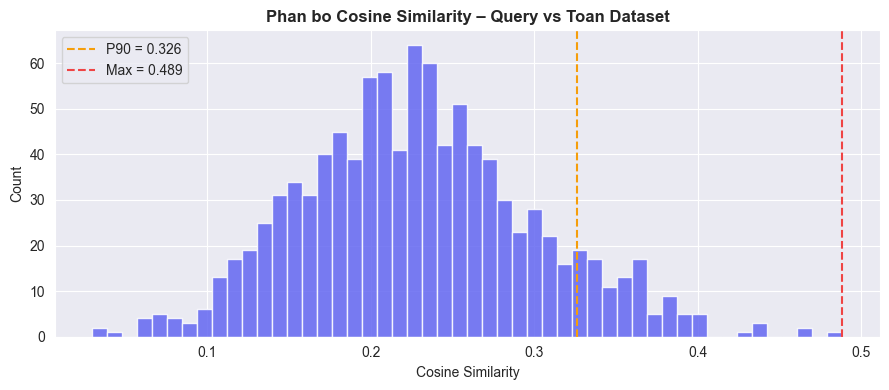

In [75]:
# 9.1 Phân bố Cosine Similarity – Query vs Toàn Dataset
q_emb_viz = encode_query("simple clean space neutral colors open areas")
sims_all  = cosine_similarity(q_emb_viz, dataset_embeddings)[0]
plt.figure(figsize=(9, 4))
plt.hist(sims_all, bins=50, color="#6366f1", edgecolor="white", alpha=0.85)
plt.axvline(np.percentile(sims_all, 90), color="#f59e0b", linestyle="--",
            label=f"P90 = {np.percentile(sims_all,90):.3f}")
plt.axvline(sims_all.max(), color="#ef4444", linestyle="--",
            label=f"Max = {sims_all.max():.3f}")
plt.xlabel("Cosine Similarity"); plt.ylabel("Count")
plt.title("Phan bo Cosine Similarity – Query vs Toan Dataset", fontweight="bold")
plt.legend(); plt.tight_layout(); plt.show()


#### 9.2 Top-10 Similarity Bar Chart theo Demo Query

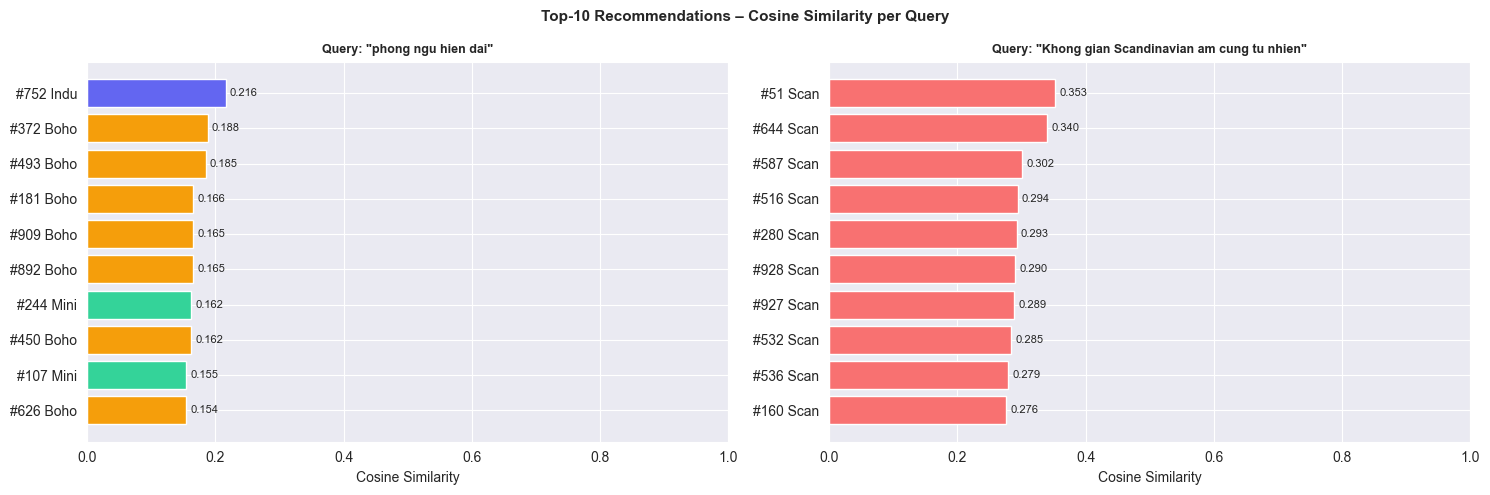

In [76]:
# 9.2 Top-10 Similarity Bar Chart theo Demo Query
DEMO_VIZ_QUERIES = [
    "phong ngu hien dai",
    "Khong gian Scandinavian am cung tu nhien",
]
style_colors_map = {"Boho":"#f59e0b","Industrial":"#6366f1",
                    "Minimalist":"#34d399","Scandinavian":"#f87171"}
fig_sim, axes_sim = plt.subplots(1, len(DEMO_VIZ_QUERIES), figsize=(15, 5))
for ax, query in zip(axes_sim, DEMO_VIZ_QUERIES):
    top_df = recommend(query, top_n=10)
    bar_colors_q = [style_colors_map.get(s, "#94a3b8") for s in top_df["style_label"]]
    labels = [f"#{int(r.Image_id)} {r.style_label[:4]}" for _, r in top_df.iterrows()]
    bars_q = ax.barh(labels, top_df["similarity"].values,
                     color=bar_colors_q, edgecolor="white")
    ax.bar_label(bars_q, fmt="%.3f", padding=3, fontsize=8)
    ax.set_xlim(0, 1); ax.set_xlabel("Cosine Similarity")
    ax.set_title(f'Query: "{query}"', fontweight="bold", fontsize=9)
    ax.invert_yaxis()
plt.suptitle("Top-10 Recommendations – Cosine Similarity per Query",
             fontweight="bold", fontsize=11)
plt.tight_layout(); plt.show()


## 10. Dashboard Tổng quan (Plotly Interactive)

Biểu đồ tổng hợp 4-panel: phân bố nhãn, feature importance, heatmap style × material.

In [77]:
# 10. Dashboard Tổng quan – Plotly 4-panel
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig_dash = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Phan bo Style","Phan bo Material",
                    "Feature Importance (Style RF)","Style x Material Heatmap"),
    specs=[[{"type":"bar"},{"type":"bar"}],
           [{"type":"bar"},{"type":"heatmap"}]]
)
sc2 = df["style_label"].value_counts()
fig_dash.add_trace(go.Bar(x=sc2.index, y=sc2.values,
    marker_color=["#6366f1","#34d399","#f59e0b","#f87171"],
    showlegend=False), row=1, col=1)
mc2 = df["material_label"].value_counts()
fig_dash.add_trace(go.Bar(x=mc2.index, y=mc2.values,
    marker_color="#60a5fa", showlegend=False), row=1, col=2)
feat_d = tfidf_style.get_feature_names_out()
fi_d   = style_clf.feature_importances_
ord_d  = np.argsort(fi_d)[-15:]
fig_dash.add_trace(go.Bar(
    y=[feat_d[i] for i in ord_d], x=fi_d[ord_d],
    orientation="h", marker_color="#a78bfa", showlegend=False), row=2, col=1)
cross_d = pd.crosstab(df["style_label"], df["material_label"])
fig_dash.add_trace(go.Heatmap(
    z=cross_d.values, x=cross_d.columns.tolist(), y=cross_d.index.tolist(),
    colorscale="Blues", showscale=True,
    text=cross_d.values, texttemplate="%{text}"), row=2, col=2)
fig_dash.update_layout(height=750, title_text="ML Design System – Tong quan Dashboard",
    title_font_size=16)
fig_dash.show()


## 11. Lưu Models & Artifacts

In [78]:

os.makedirs("models", exist_ok=True)

joblib.dump(style_clf,    "models/style_model.pkl")
joblib.dump(material_clf, "models/material_model.pkl")
joblib.dump(color_reg,    "models/color_model.pkl")
joblib.dump(tfidf_style,  "models/tfidf_style.pkl")
joblib.dump(tfidf_material, "models/tfidf_material.pkl")

joblib.dump({
    "style_names":      STYLE_NAMES,
    "material_names":   MATERIAL_NAMES,
    "st_model_name":    "all-MiniLM-L6-v2",
    "color_palette":    COLOR_PALETTE_TABLE,
}, "models/metadata.pkl")

print("Đã lưu models thành công!")


Đã lưu models thành công!


---

## Tóm tắt pipeline

| Bước | Module | Mô tả |
|---|---|---|
| 1 | `build_feature_vector()` | Keyword matching → (1×12) feature vector |
| 2 | `style_clf` (RF) | Phân loại phong cách thiết kế (4 nhãn) |
| 3 | `material_clf` (RF) | Phân loại vật liệu (8 nhãn) |
| 4 | `color_reg` (MultiOutput RF) | Dự đoán 3 màu RGB |
| 5 | `SentenceTransformer` | Encode query → vector 384d |
| 6 | `cosine_similarity()` | Tìm Top-N mẫu tương đồng nhất |

### Giá trị học thuật
- End-to-end ML pipeline: NLP + Classification + Regression + Similarity Search
- Kết hợp supervised learning (RF) với semantic search (Sentence-BERT)
- MultiOutput regression cho bài toán dự đoán đa mục tiêu
- Hybrid filtering: ML prediction filter → vector similarity ranking
